Upload Dataset

In [126]:
from google.colab import files

uploaded = files.upload()

Saving data.csv to data (5).csv


Import Libraries

In [127]:
# Read and handle dataset
import pandas as pd

# Numerical operations
import numpy as np

# Plot graphs
import matplotlib.pyplot as plt


# Split dataset
from sklearn.model_selection import train_test_split

# Scale features
from sklearn.preprocessing import StandardScaler

# Model evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


# PyTorch main library
import torch

# Neural network layers
import torch.nn as nn

# Optimizers
import torch.optim as optim

Load Dataset

In [128]:
# Read dataset from CSV file
df = pd.read_csv("data.csv")


# Display first 5 rows
print("First 5 rows:")
print(df.head())


# Display dataset dimensions
# (rows, columns)
print("\nDataset Shape:")
print(df.shape)

First 5 rows:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_wor

Check Missing Values

In [129]:
# Check missing values in each column
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_wors

Clean Dataset

In [130]:
# Remove unnecessary columns
df.drop(columns=["id", "Unnamed: 32"], inplace=True)


# Display remaining columns
print("\nColumns after cleaning:")
print(df.columns)


Columns after cleaning:
Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')


Encode Labels

In [131]:
# Convert labels to numbers
# M = 1 , B = 0

df["diagnosis"] = df["diagnosis"].map({
    "M": 1,
    "B": 0
})


# Display label counts
print("\nDiagnosis Counts:")
print(df["diagnosis"].value_counts())


Diagnosis Counts:
diagnosis
0    357
1    212
Name: count, dtype: int64


Features and Labels

In [132]:
# Separate features and labels

X = df.drop("diagnosis", axis=1).values
y = df["diagnosis"].values


# Display data shapes
print("\nFeatures Shape:", X.shape)
print("Labels Shape:", y.shape)


Features Shape: (569, 30)
Labels Shape: (569,)


Train / Validation / Test Split

In [133]:
# Split data into:
# Train, Validation, and Test

X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)


# Display dataset shapes
print("\nTrain Shape:", X_train.shape)
print("Validation Shape:", X_val.shape)
print("Test Shape:", X_test.shape)


Train Shape: (341, 30)
Validation Shape: (114, 30)
Test Shape: (114, 30)


Feature Scaling

In [134]:
# Scale feature values

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

Convert to Tensors

In [135]:
# Convert data to PyTorch tensors

X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train).view(-1, 1)

X_val = torch.FloatTensor(X_val)
y_val = torch.FloatTensor(y_val).view(-1, 1)

X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test).view(-1, 1)


# Display tensor shapes
print(X_train.shape)
print(y_train.shape)

torch.Size([341, 30])
torch.Size([341, 1])


Build MLP Model

In [136]:
# Build MLP model

class MLP(nn.Module):

    def __init__(self):
        super(MLP, self).__init__()

        self.model = nn.Sequential(

            # Input layer
            nn.Linear(30, 32),

            # Normalize data
            nn.BatchNorm1d(32),

            # Activation function
            nn.ReLU(),

            # Reduce overfitting
            nn.Dropout(0.3),

            # Hidden layer
            nn.Linear(32, 16),

            # Normalize data
            nn.BatchNorm1d(16),

            # Activation function
            nn.ReLU(),

            # Reduce overfitting
            nn.Dropout(0.3),

            # Output layer
            nn.Linear(16, 1),

            # Binary classification output
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


# Create model
model = MLP()


# Display model architecture
print(model)

MLP(
  (model): Sequential(
    (0): Linear(in_features=30, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=16, out_features=1, bias=True)
    (9): Sigmoid()
  )
)


Loss Function and Optimizer

In [137]:
# Loss function
criterion = nn.BCELoss()


# Adam optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)


# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

Training Setup

In [138]:
# Number of training epochs
epochs = 100


# Store training and validation loss
train_losses = []
val_losses = []


# Store training and validation accuracy
train_accuracies = []
val_accuracies = []


# Best validation loss value
best_val_loss = float('inf')


# Early stopping settings
patience = 10
counter = 0

Training Loop

In [139]:
# Training loop

for epoch in range(epochs):

    # Enable training mode
    model.train()


    # Clear old gradients
    optimizer.zero_grad()


    # Forward pass
    outputs = model(X_train)


    # Calculate loss
    loss = criterion(outputs, y_train)


    # Backpropagation
    loss.backward()


    # Update weights
    optimizer.step()


    # Calculate training accuracy
    predicted_train = (outputs >= 0.5).float()

    train_acc = (
        predicted_train.eq(y_train).sum().item()
        / y_train.shape[0]
    )


    # Enable evaluation mode
    model.eval()

    with torch.no_grad():

        # Validation predictions
        val_outputs = model(X_val)


        # Validation loss
        val_loss = criterion(val_outputs, y_val)


        # Validation accuracy
        predicted_val = (val_outputs >= 0.5).float()

        val_acc = (
            predicted_val.eq(y_val).sum().item()
            / y_val.shape[0]
        )


    # Save metrics
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)


    # Update learning rate
    scheduler.step(val_loss)


    # Early stopping
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        # Save best model
        torch.save(model.state_dict(), "best_model.pth")

        counter = 0

    else:
        counter += 1


    # Stop training if needed
    if counter >= patience:

        print("\nEarly stopping triggered!")

        break


    # Print training results
    if (epoch + 1) % 10 == 0:

        print(f"Epoch [{epoch+1}/{epochs}]")

        print(f"Train Loss: {loss.item():.4f}")

        print(f"Validation Loss: {val_loss.item():.4f}")

        print(f"Train Accuracy: {train_acc:.4f}")

        print(f"Validation Accuracy: {val_acc:.4f}")

        print("-" * 40)

Epoch [10/100]
Train Loss: 0.5703
Validation Loss: 0.5977
Train Accuracy: 0.7801
Validation Accuracy: 0.8158
----------------------------------------
Epoch [20/100]
Train Loss: 0.4704
Validation Loss: 0.4855
Train Accuracy: 0.9062
Validation Accuracy: 0.9298
----------------------------------------
Epoch [30/100]
Train Loss: 0.4079
Validation Loss: 0.3949
Train Accuracy: 0.9296
Validation Accuracy: 0.9474
----------------------------------------
Epoch [40/100]
Train Loss: 0.3717
Validation Loss: 0.3432
Train Accuracy: 0.9413
Validation Accuracy: 0.9649
----------------------------------------
Epoch [50/100]
Train Loss: 0.3346
Validation Loss: 0.3112
Train Accuracy: 0.9501
Validation Accuracy: 0.9737
----------------------------------------
Epoch [60/100]
Train Loss: 0.3143
Validation Loss: 0.2873
Train Accuracy: 0.9472
Validation Accuracy: 0.9737
----------------------------------------
Epoch [70/100]
Train Loss: 0.2840
Validation Loss: 0.2680
Train Accuracy: 0.9795
Validation Accuracy

Load Best Model

In [140]:
# Load best saved model
model.load_state_dict(torch.load("best_model.pth"))

<All keys matched successfully>

Test Evaluation

In [141]:
# Enable evaluation mode
model.eval()


# Disable gradient calculation
with torch.no_grad():

    # Test predictions
    test_outputs = model(X_test)


    # Calculate test loss
    test_loss = criterion(test_outputs, y_test)


    # Convert predictions to 0 or 1
    predicted_test = (test_outputs >= 0.5).float()

Accuracy

In [142]:
# Calculate test accuracy
test_accuracy = (
    predicted_test.eq(y_test).sum().item()
    / y_test.shape[0]
)


# Display test results
print("\n==============================")
print("TEST RESULTS")
print("==============================")


# Print accuracy
print(f"Test Accuracy: {test_accuracy:.4f}")


# Print loss
print(f"Final Test Loss: {test_loss.item():.4f}")


TEST RESULTS
Test Accuracy: 0.9737
Final Test Loss: 0.2250


Classification Report

In [143]:
# Convert tensors to numpy arrays
y_true = y_test.numpy()

y_pred = predicted_test.numpy()


# Display classification report
print("\nClassification Report:")

print(classification_report(y_true, y_pred))


Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      0.99      0.98        72
         1.0       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



Confusion Matrix

In [144]:
# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)


# Display confusion matrix
print("\nConfusion Matrix:")

print(cm)


Confusion Matrix:
[[71  1]
 [ 2 40]]


Loss Curve

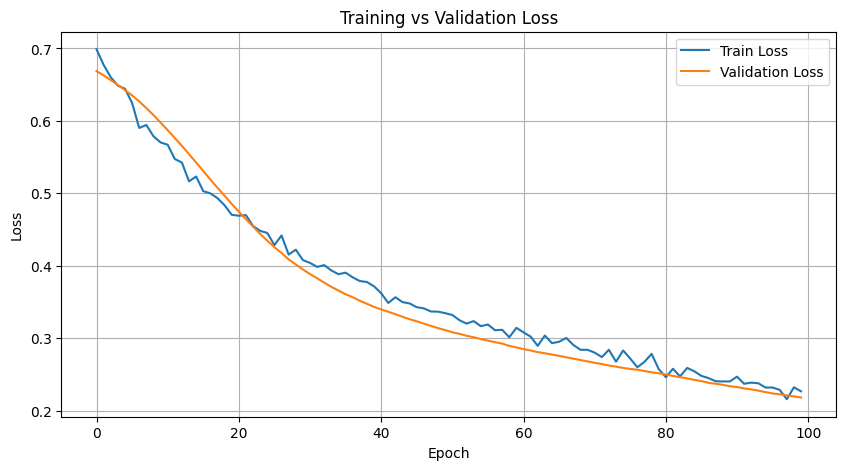

In [145]:
# Create loss curve figure
plt.figure(figsize=(10, 5))


# Plot training loss
plt.plot(train_losses, label="Train Loss")


# Plot validation loss
plt.plot(val_losses, label="Validation Loss")


# X-axis label
plt.xlabel("Epoch")


# Y-axis label
plt.ylabel("Loss")


# Graph title
plt.title("Training vs Validation Loss")


# Show legend
plt.legend()


# Show grid
plt.grid(True)


# Display graph
plt.show()

Accuracy Curve

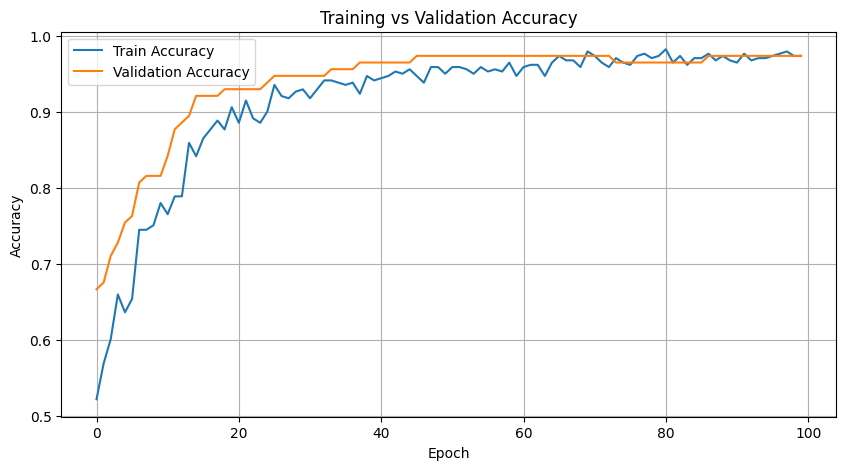

In [146]:
# Create accuracy curve figure
plt.figure(figsize=(10, 5))


# Plot training accuracy
plt.plot(train_accuracies, label="Train Accuracy")


# Plot validation accuracy
plt.plot(val_accuracies, label="Validation Accuracy")


# X-axis label
plt.xlabel("Epoch")


# Y-axis label
plt.ylabel("Accuracy")


# Graph title
plt.title("Training vs Validation Accuracy")


# Show legend
plt.legend()


# Show grid
plt.grid(True)


# Display graph
plt.show()

Experiment 1 (Activation Function)

In [147]:
"""
Experiment 1

Change:
nn.ReLU()

To:
nn.Tanh()

Then compare:
- Accuracy
- Loss
- Stability
"""

'\nExperiment 1\n\nChange:\nnn.ReLU()\n\nTo:\nnn.Tanh()\n\nThen compare:\n- Accuracy\n- Loss\n- Stability\n'

Experiment 2 (Neurons)

In [148]:
"""
Experiment 2

Change:
30 -> 32 -> 16 -> 1

To:
30 -> 64 -> 32 -> 1

Then compare:
- Accuracy
- Loss
- Overfitting
"""

'\nExperiment 2\n\nChange:\n30 -> 32 -> 16 -> 1\n\nTo:\n30 -> 64 -> 32 -> 1\n\nThen compare:\n- Accuracy\n- Loss\n- Overfitting\n'

Experiment 3 (Learning Rate)

In [149]:
"""
Experiment 3

Change:
lr = 0.001

To:
lr = 0.01

Then compare:
- Convergence Speed
- Stability
- Final Accuracy
"""

'\nExperiment 3\n\nChange:\nlr = 0.001\n\nTo:\nlr = 0.01\n\nThen compare:\n- Convergence Speed\n- Stability\n- Final Accuracy\n'

Final Message

In [150]:
print("Project Completed Successfully!")

Project Completed Successfully!
